In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel #, Matern
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [ ]:
#Function to add data points each week.
current_week = 14 # CHANGE THIS EACH WEEK

# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_4\initial_inputs.npy")
    Y = np.load(r"function_4\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_4/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_4/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")


In [8]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================


np.save(
    f"function_4/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_4/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_4/w{current_week}_inputs.npy"
)

print(
    f"function_4/w{current_week}_outputs.npy"
)


Saved files:
function_4/w14_inputs.npy
function_4/w14_outputs.npy


In [9]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_4/w14_inputs.npy")
Y = np.load("function_4/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.8f} | Gap={abs(Y[i]):.8f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:      {np.max(Y):.8f}")
print(f"Gap to zero: {abs(np.max(Y)):.8f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | "
          f"Y={Y[i]:.8f} | X={vals}")

print("\nKey dimension values in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.8f} | "
          f"x1={X[i,0]:.6f} | "
          f"x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f}")

All points ranked best to worst:
  Y=0.72304473 | Gap=0.72304473 | X=0.418288-0.413466-0.416532-0.422853
  Y=0.71799587 | Gap=0.71799587 | X=0.414756-0.412940-0.412857-0.423320
  Y=0.70966447 | Gap=0.70966447 | X=0.419230-0.412643-0.410077-0.422899
  Y=0.70593144 | Gap=0.70593144 | X=0.422431-0.414135-0.413653-0.423129
  Y=0.69601148 | Gap=0.69601148 | X=0.410237-0.410755-0.412818-0.423538
  Y=0.69459266 | Gap=0.69459266 | X=0.423786-0.414789-0.418567-0.422956
  Y=0.60899922 | Gap=0.60899922 | X=0.394444-0.410152-0.416741-0.424299
  Y=0.59749748 | Gap=0.59749748 | X=0.396511-0.406491-0.414875-0.421474
  Y=0.47085616 | Gap=0.47085616 | X=0.395215-0.404568-0.417785-0.432795
  Y=0.46378290 | Gap=0.46378290 | X=0.344349-0.382259-0.428575-0.426367
  Y=0.19749568 | Gap=0.19749568 | X=0.426033-0.437128-0.361809-0.444549
  Y=0.16368467 | Gap=0.16368467 | X=0.374827-0.405638-0.434915-0.443642
  Y=-1.54488799 | Gap=1.54488799 | X=0.434087-0.423158-0.247207-0.435470
  Y=-4.02554228 | Gap=4.025542

## Dynamic BO Windowing — Function 4

The windowing mechanism for Function 4 underwent two iterations before 
converging on the region-based filter used in the final rounds. The problem 
here was the function's **dynamic nature** and that it could change weekly. 

An initial **time-based sliding window** (k=10 most recent observations) was 
implemented inspired by Bogunovic et al. (2016) but failed in practice because 
recent exploratory queries outside the positive region introduced Y=−23 
negatives into the fitting window. With only 10 observations and a Y range 
spanning from −23 to +0.72, the surrogate was fitting an average of multiple 
landscape configurations rather than the current one. A **LOO RMSE of 5.204** 
confirmed this failure.

The **region-based filter** replaced the time window — only observations within 
a Euclidean distance threshold of the confirmed best point were included in 
surrogate fitting, regardless of query order.

Region window: 11 observations within dist=0.08 of best point
Window Y range: 0.163685 to 0.723045


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Fitted kernel length scales (window):
  x1: 1.6401
  x2: 1.7150
  x3: 10.0000 ← hitting bound
  x4: 2.9727

Best real point (all history): [0.418288 0.413466 0.416532 0.422853]
Best real Y (all history):     0.723045
Best Y in window:              0.723045


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-p


=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 0.123845
SVR LOO RMSE: 0.112447
Primary surrogate: SVR
Novel candidates (local): 298604
Novel candidates (uniform): 299658

FULL COMPARISON — Function 4

--- GP (local) ---
  Suggestion:         0.408492-0.422715-0.477821-0.406026
  Predicted Y:        0.863911
  Distance from best: 0.0650
  x1=0.4085 | x2=0.4227 | x3=0.4778 | x4=0.4060

--- SVR (local) ---
  Suggestion:         0.423786-0.414789-0.418567-0.422956
  Predicted Y:        0.708450
  Distance from best: 0.0060
  x1=0.4238 | x2=0.4148 | x3=0.4186 | x4=0.4230

--- SVR (uniform) ---
  Suggestion:         0.425246-0.416298-0.418237-0.422744
  Predicted Y:        0.704449
  Distance from best: 0.0077
  x1=0.4252 | x2=0.4163 | x3=0.4182 | x4=0.4227

SUBMISSION SELECTION
Plausibility bounds: [0.5061, 0.9400]
  GP (local): excluded — dist=0.0650 > 0.06 | pred=0.8639 | plausible=True
  SVR (local): eligible | pred=0.7084 | plausible=True
  SVR (uniform): eligible | pred=0.7044 | plausible

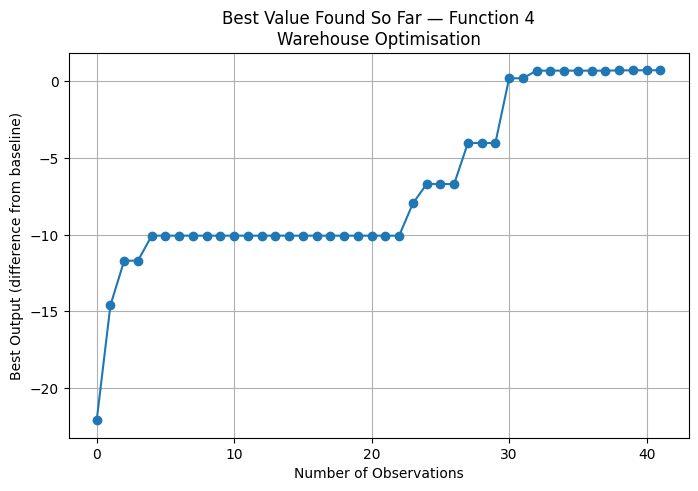

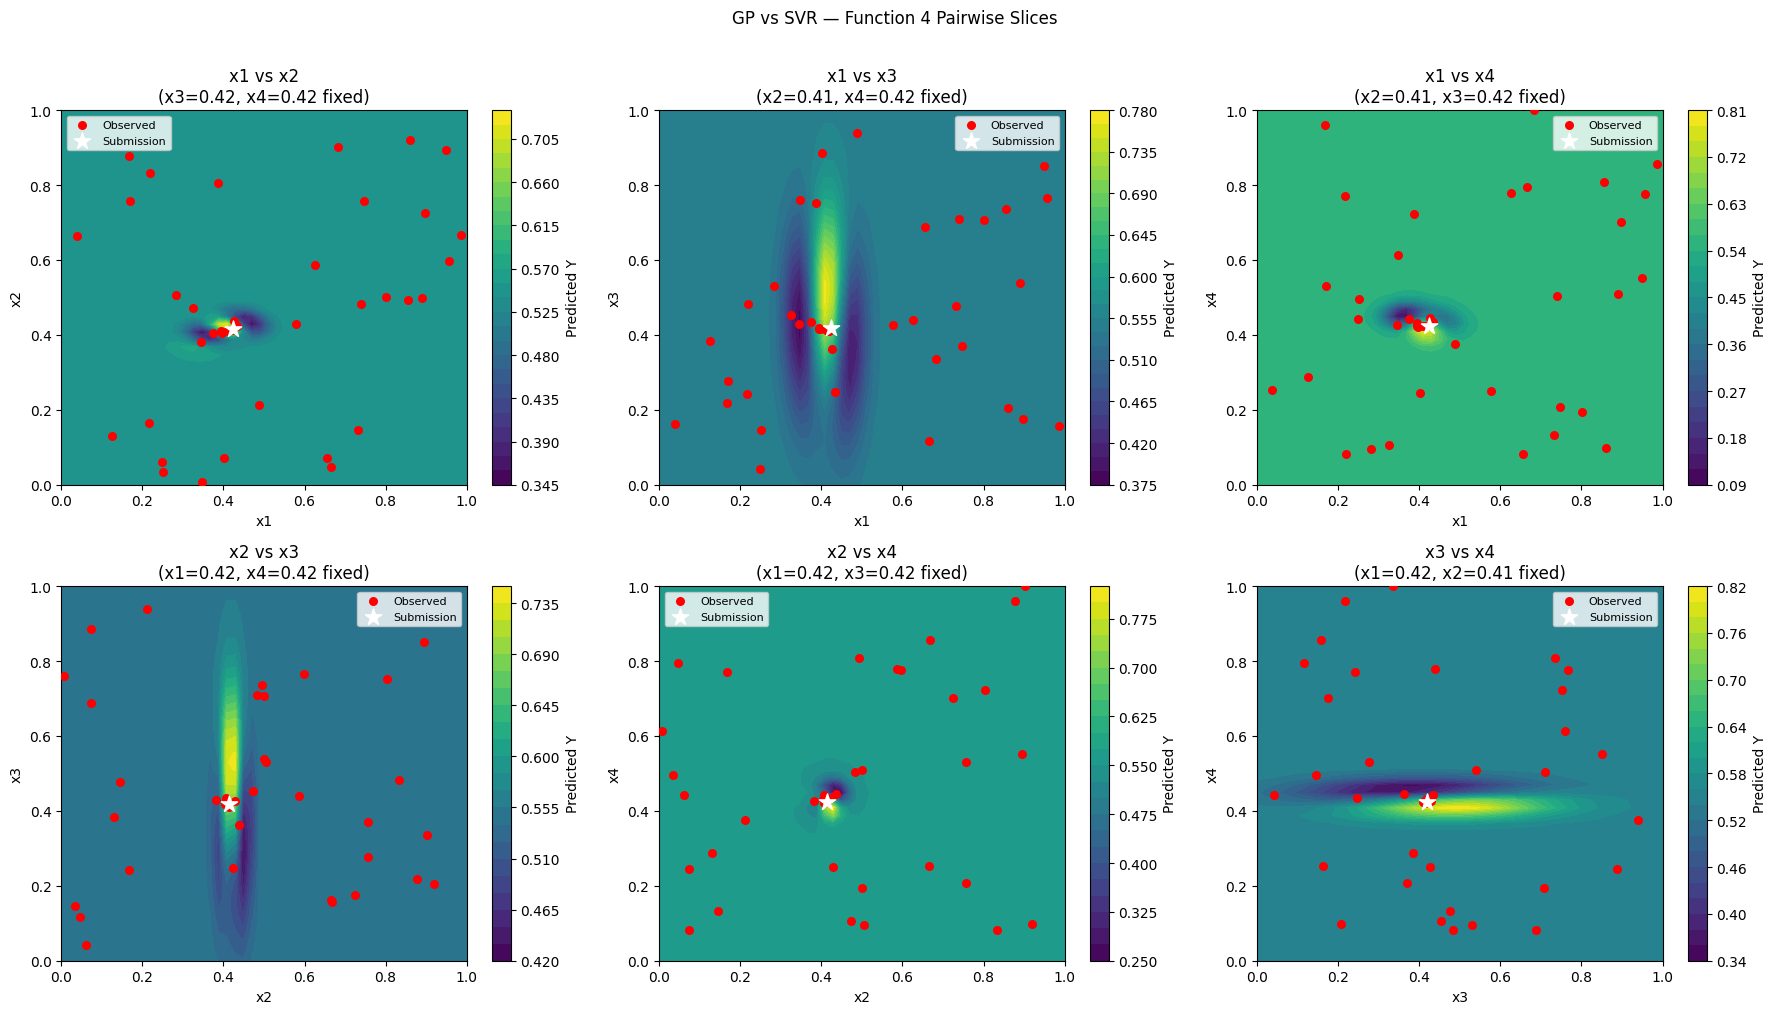


Top 5 real evaluated points:
  Y=0.723045 | X=0.4183-0.4135-0.4165-0.4229
  Y=0.717996 | X=0.4148-0.4129-0.4129-0.4233
  Y=0.709664 | X=0.4192-0.4126-0.4101-0.4229
  Y=0.705931 | X=0.4224-0.4141-0.4137-0.4231
  Y=0.696011 | X=0.4102-0.4108-0.4128-0.4235


In [5]:
# adding the dynamic GP
# =====================================================
# FUNCTION 4 — 4D Warehouse Optimisation (dynamic)
# Week 9: length_scale_bounds tightened (1e-3, 10.0)
# Week 9: plausibility check added to selection logic
# Week 10: sliding window Dynamic BO added
#          only last k observations used for fitting
#          older data down-weighted — landscape shifts
#          Reference: Bogunovic et al. (2016)
# Note: HEBO/Optuna not applied — dynamic function
# means historical observations reflect a shifting
# landscape, which would mislead learned surrogates
# =====================================================

# =====================================================
# GP MODEL — check kernel length scales each week
# Week 7: tighten search around known good points
# Week 9: length_scale_bounds tightened to (1e-3, 10)
#         prevents dimensions hitting upper bound
# =====================================================
kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=[0.1, 0.1, 0.1, 0.1],
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# ACQUISITION FUNCTION
# =====================================================
def expected_improvement(X_candidates_scaled, gp,
                          Y_ref, xi=0.05):
    mean, std = gp.predict(X_candidates_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# SLIDING WINDOW — Dynamic BO week 10
# Standard BO assumes landscape is stable — F4 is
# explicitly dynamic (landscape shifts each week).
# Fitting on all 38 observations includes data from
# very different landscape configurations, causing
# high LOO RMSE (1.437) and unreliable suggestions.
#
# Solution: use only the most recent k observations
# so the surrogate reflects the current landscape
# rather than an average of many past landscapes.
#
# k=10: balances recency vs data sparsity
#   too small (k<6): GP unstable with 4D function
#   too large (k>15): includes too many stale obs
#
# best_point kept from full history — we still want
# to know the all-time best for candidate generation
# even if the surrogate only sees recent data
# =====================================================
#k = 10  # sliding window size — tune each week

#best_point = X[np.argmax(Y)]   # from full history
#best_Y_all = np.max(Y)         # from full history

#if len(Y) > k:
#    X_window = X[-k:]
#    Y_window = Y[-k:]
#    print(f"Sliding window: using last {k} of "
#          f"{len(Y)} observations")
#    print(f"Window Y range: {np.min(Y_window):.4f} "
#          f"to {np.max(Y_window):.4f}")
#else:
#    X_window = X
#    Y_window = Y
#    print(f"Sliding window: using all {len(Y)} "
#          f"observations (below window size {k})")
best_point = X[np.argmax(Y)]   # from full history
best_Y_all = np.max(Y)         # from full history
k = 8                 # approx window size for reporting

dist_to_best = np.linalg.norm(X - best_point, axis=1)
region_mask  = dist_to_best <= 0.09  # confirmed positive region
X_window     = X[region_mask]
Y_window     = Y[region_mask]

print(f"Region window: {len(Y_window)} observations "
      f"within dist=0.08 of best point")
print(f"Window Y range: {np.min(Y_window):.6f} "
      f"to {np.max(Y_window):.6f}")
# =====================================================
# FIT GP AND SVR ON WINDOW ONLY
# =====================================================
np.random.seed(42)
n_candidates = 300000

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_window)
gp.fit(X_scaled, Y_window)

# Print kernel length scales — track each week
# Flag threshold updated to 9.5 to match new bound
print("\nFitted kernel length scales (window):")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 9.5 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100,
          epsilon=0.01, gamma='scale')
svr.fit(X_scaled, Y_window)

print(f"\nBest real point (all history): {best_point}")
print(f"Best real Y (all history):     {best_Y_all:.6f}")
print(f"Best Y in window:              "
      f"{np.max(Y_window):.6f}")

# =====================================================
# LOO CROSS VALIDATION — on window only
# Window data only — LOO on full 38 obs would
# include stale landscape data that inflates RMSE
# =====================================================
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist

loo        = LeaveOneOut()
gp_errors  = []
svr_errors = []

for train_idx, test_idx in loo.split(X_window):
    X_train, X_test = X_window[train_idx], X_window[test_idx]
    Y_train, Y_test = Y_window[train_idx], Y_window[test_idx]

    scaler_cv = StandardScaler()
    X_train_s = scaler_cv.fit_transform(X_train)
    X_test_s  = scaler_cv.transform(X_test)

    gp_cv = GaussianProcessRegressor(
        kernel=kernel, random_state=42,
        normalize_y=True, alpha=1e-6)
    gp_cv.fit(X_train_s, Y_train)
    gp_errors.append(
        (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)

    svr_cv = SVR(kernel='rbf', C=100,
                 epsilon=0.01, gamma='scale')
    svr_cv.fit(X_train_s, Y_train)
    svr_errors.append(
        (svr_cv.predict(X_test_s)[0] - Y_test[0])**2)

gp_rmse  = np.sqrt(np.mean(gp_errors))
svr_rmse = np.sqrt(np.mean(svr_errors))
primary_model = "GP" if gp_rmse < svr_rmse else "SVR"

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.6f}")
print(f"SVR LOO RMSE: {svr_rmse:.6f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# GENERATE CANDIDATES — three approaches
# Five positive results within 0.074 of best
# x1 near 0.41 confirmed better than 0.39
# All dimensions confirmed near 0.41-0.43
# =====================================================

# Local noise — tight std=0.015 given peak width
n_local  = int(n_candidates * 0.7)
n_random = n_candidates - n_local

noise    = np.random.normal(0, 0.015,
                             size=(n_local, dim))
X_local  = np.clip(best_point + noise, 0.0, 0.999999)
X_random = np.random.uniform(0.35, 0.48,
                              size=(n_random, dim))

X_candidates   = np.vstack([X_local, X_random])
# Novelty filter uses full X history — don't requery
# any point ever submitted regardless of window
min_dists      = cdist(X_candidates, X).min(axis=1)
X_novel        = X_candidates[min_dists >= 0.005]
X_novel_scaled = scaler.transform(X_novel)

print(f"Novel candidates (local): {len(X_novel)}")

# Uniform sampling within confirmed good ranges
# x1: 0.344-0.426 → search 0.37-0.43
# x2: 0.382-0.437 → search 0.37-0.45
# x3: 0.362-0.435 → search 0.35-0.45
# x4: 0.424-0.445 → search 0.41-0.46
x1_u = np.random.uniform(0.37, 0.43, n_candidates)
x2_u = np.random.uniform(0.37, 0.45, n_candidates)
x3_u = np.random.uniform(0.35, 0.45, n_candidates)
x4_u = np.random.uniform(0.41, 0.46, n_candidates)

X_uniform   = np.column_stack([x1_u, x2_u,
                                x3_u, x4_u])
min_dists_u = cdist(X_uniform, X).min(axis=1)
X_novel_u   = X_uniform[min_dists_u >= 0.005]
X_novel_u_s = scaler.transform(X_novel_u)

print(f"Novel candidates (uniform): {len(X_novel_u)}")

# =====================================================
# SCORE ALL CANDIDATE SETS
# =====================================================

# Local noise — GP EI
ei_scores   = expected_improvement(
    X_novel_scaled, gp, Y, xi=0.05)
x_submit_gp = X_novel[np.argmax(ei_scores)]
pred_gp     = gp.predict(
    scaler.transform([x_submit_gp]))[0]
dist_gp     = np.linalg.norm(x_submit_gp - best_point)

# Local noise — SVR
svr_scores   = svr.predict(X_novel_scaled)
x_submit_svr = X_novel[np.argmax(svr_scores)]
pred_svr     = svr.predict(
    scaler.transform([x_submit_svr]))[0]
dist_svr     = np.linalg.norm(x_submit_svr - best_point)

# Uniform ranges — SVR
svr_scores_u = svr.predict(X_novel_u_s)
x_submit_u   = X_novel_u[np.argmax(svr_scores_u)]
pred_u       = svr.predict(
    scaler.transform([x_submit_u]))[0]
dist_u       = np.linalg.norm(x_submit_u - best_point)

# =====================================================
# FULL COMPARISON
# =====================================================
print("\n" + "="*55)
print("FULL COMPARISON — Function 4")
print("="*55)

all_options = {
    "GP (local)":    (x_submit_gp,  pred_gp,  dist_gp),
    "SVR (local)":   (x_submit_svr, pred_svr, dist_svr),
    "SVR (uniform)": (x_submit_u,   pred_u,   dist_u)
}

for name, (x_sub, pred, dist) in all_options.items():
    print(f"\n--- {name} ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  Predicted Y:        {pred:.6f}")
    print(f"  Distance from best: {dist:.4f}")
    print(f"  x1={x_sub[0]:.4f} | x2={x_sub[1]:.4f} | "
          f"x3={x_sub[2]:.4f} | x4={x_sub[3]:.4f}")

# =====================================================
# SUBMISSION SELECTION
# Eligible = within 0.06 of best point
# Tighter than before — five results confirm
# peak is narrow, within 0.074 of best
#
# PLAUSIBILITY CHECK — added week 9
# Dynamic function makes surrogates prone to
# underestimating — same SVR issue seen in F5/F7.
# Floor: 70% of best real Y
# Ceiling: 130% of best real Y
# If primary model fails — pick highest plausible
# alternative among remaining eligible candidates.
# =====================================================
threshold = 0.06

# Plausibility uses full history best — we want to
# beat the all-time best, not just the window best
best_real_y        = best_Y_all
plausibility_floor = 0.70 * best_real_y
plausibility_ceil  = 1.30 * best_real_y

def plausible(pred):
    """Prediction is within plausibility bounds."""
    return plausibility_floor <= pred <= plausibility_ceil

print(f"\n{'='*55}")
print("SUBMISSION SELECTION")
print(f"{'='*55}")
print(f"Plausibility bounds: "
      f"[{plausibility_floor:.4f}, "
      f"{plausibility_ceil:.4f}]")

candidates_final = []
for name, (x_sub, pred, dist) in all_options.items():
    eligible = dist <= threshold
    status   = "eligible" if eligible \
               else f"excluded — dist={dist:.4f} > {threshold}"
    print(f"  {name}: {status} | "
          f"pred={pred:.4f} | "
          f"plausible={plausible(pred)}")
    if eligible:
        candidates_final.append(
            (name, x_sub, pred, dist))

if len(candidates_final) == 0:
    print("No candidates eligible — proximity search")
    noise_ps     = np.random.normal(0, 0.01,
                                     size=(500000, dim))
    X_ps         = np.clip(best_point + noise_ps,
                            0.0, 0.999999)
    min_dists_ps = cdist(X_ps, X).min(axis=1)
    X_novel_ps   = X_ps[min_dists_ps >= 0.003]
    X_novel_ps_s = scaler.transform(X_novel_ps)
    ei_ps        = expected_improvement(
        X_novel_ps_s, gp, Y, xi=0.001)
    x_final      = X_novel_ps[np.argmax(ei_ps)]
    chosen_model = "Proximity search (fallback)"
else:
    # Step 1 — find primary model eligible candidates
    primary_eligible = [
        c for c in candidates_final
        if primary_model.upper() in c[0].upper()]

    # Step 2 — filter to plausible only
    primary_plausible = [
        c for c in primary_eligible
        if plausible(c[2])]

    if primary_plausible:
        # Primary model eligible and plausible — use it
        best_eligible = max(primary_plausible,
                            key=lambda t: t[2])
        x_final      = best_eligible[1]
        chosen_model = (f"{best_eligible[0]} "
                        f"(LOO primary)")
    else:
        # Primary model failed plausibility — override
        # Pick highest plausible among all eligible
        all_plausible = [
            c for c in candidates_final
            if plausible(c[2])]
        if all_plausible:
            best_eligible = max(all_plausible,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(plausibility override)")
            print(f"\n⚠ Primary model failed "
                  f"plausibility check — "
                  f"overriding to {best_eligible[0]}")
        else:
            # All implausible — fall back to closest
            best_eligible = max(candidates_final,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(all implausible — "
                            f"highest pred)")

submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - best_point)

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP  predicted Y:    {pred_gp:.6f}")
print(f"SVR predicted Y:    {pred_svr:.6f}")
print(f"Best real Y (all):  {best_Y_all:.6f}")
print(f"Best Y in window:   {np.max(Y_window):.6f}")
print(f"Window size:        {len(Y_window)} of {len(Y)} observations")
print(f"Distance from best: {dist_final:.6f}")
print(f"x1={x_final[0]:.4f} | x2={x_final[1]:.4f} | "
      f"x3={x_final[2]:.4f} | x4={x_final[3]:.4f}")
print(f"LOO primary model:  {primary_model} "
      f"(GP={gp_rmse:.4f}, SVR={svr_rmse:.4f})")
print(f"Plausibility floor: {plausibility_floor:.4f}")
print(f"Plausibility ceil:  {plausibility_ceil:.4f}")
print(f"Dataset size:       {len(Y)}")

# =====================================================
# PLOT 1 — optimisation progress
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.title("Best Value Found So Far — Function 4\n"
          "Warehouse Optimisation")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output (difference from baseline)")
plt.grid(True)
plt.show()

# =====================================================
# PLOT 2 — pairwise slices for 4D function
# =====================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

pairs  = [(0,1,2,3), (0,2,1,3), (0,3,1,2),
          (1,2,0,3), (1,3,0,2), (2,3,0,1)]
labels = ['x1', 'x2', 'x3', 'x4']

for ax, (xi_idx, xj_idx, f1, f2) in zip(axes, pairs):
    xi_range = np.linspace(0, 1, 50)
    xj_range = np.linspace(0, 1, 50)
    xxi, xxj = np.meshgrid(xi_range, xj_range)

    grid = np.zeros((xxi.size, dim))
    grid[:, xi_idx] = xxi.ravel()
    grid[:, xj_idx] = xxj.ravel()
    grid[:, f1]     = best_point[f1]
    grid[:, f2]     = best_point[f2]

    grid_scaled  = scaler.transform(grid)
    mean_pred, _ = gp.predict(grid_scaled,
                               return_std=True)

    cf = ax.contourf(xxi, xxj,
                     mean_pred.reshape(xxi.shape),
                     levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Predicted Y")
    ax.scatter(X[:, xi_idx], X[:, xj_idx],
               c="red", s=30, zorder=5,
               label="Observed")
    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c="white", s=150, marker="*",
               zorder=6, label="Submission")
    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])
    ax.set_title(
        f"{labels[xi_idx]} vs {labels[xj_idx]}\n"
        f"({labels[f1]}={best_point[f1]:.2f}, "
        f"{labels[f2]}={best_point[f2]:.2f} fixed)")
    ax.legend(fontsize=8)

plt.suptitle("GP vs SVR — Function 4 Pairwise Slices",
             y=1.01)
plt.tight_layout()
plt.show()

# =====================================================
# TOP 5 REAL RESULTS
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 real evaluated points:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.6f} | X={vals}")